## Imports

In [7]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


In [8]:
test_predictions = pd.read_csv(
    "../reports/FD001/fd001_test_predictions.csv"
)

print("Shape:", test_predictions.shape)
display(test_predictions.head())

Shape: (100, 6)


,unit,cycle,actual_rul,predicted_rul,error,absolute_error
0,1,31,112,176.189090,-64.189087,64.189087
1,2,49,98,151.396060,-53.396057,53.396057
2,3,126,69,53.929405,15.070595,15.070595
3,4,106,82,82.878760,-0.878761,0.878761
4,5,98,91,105.071910,-14.071907,14.071907


## Defininig the prototype risk thresholds

In [9]:
def classify_risk(predicted_rul):
    if predicted_rul > 100:
        return "NORMAL"
    elif predicted_rul > 50:
        return "MONITOR"
    else:
        return "HIGH MAINTENANCE PRIORITY"

test_predictions["maintenance_risk"] = (
test_predictions["predicted_rul"]
.apply(classify_risk)
)

display(
    test_predictions[
        [
            "unit",
            "cycle",
            "predicted_rul",
            "maintenance_risk"
        ]
    ].head(10)
)

,unit,cycle,predicted_rul,maintenance_risk
0,1,31,176.189090,NORMAL
1,2,49,151.396060,NORMAL
2,3,126,53.929405,MONITOR
3,4,106,82.878760,MONITOR
4,5,98,105.071910,NORMAL
5,6,105,90.133580,MONITOR
6,7,160,104.181550,NORMAL
7,8,166,70.679380,MONITOR
8,9,55,137.881420,NORMAL
9,10,192,116.743385,NORMAL


In [10]:
risk_counts = (
    test_predictions["maintenance_risk"]
    .value_counts()
    .reindex(
        [
            "NORMAL",
            "MONITOR",
            "HIGH MAINTENANCE PRIORITY"
        ],
        fill_value=0
    )
)

print(risk_counts)

maintenance_risk
NORMAL                       38
MONITOR                      32
HIGH MAINTENANCE PRIORITY    30
Name: count, dtype: int64


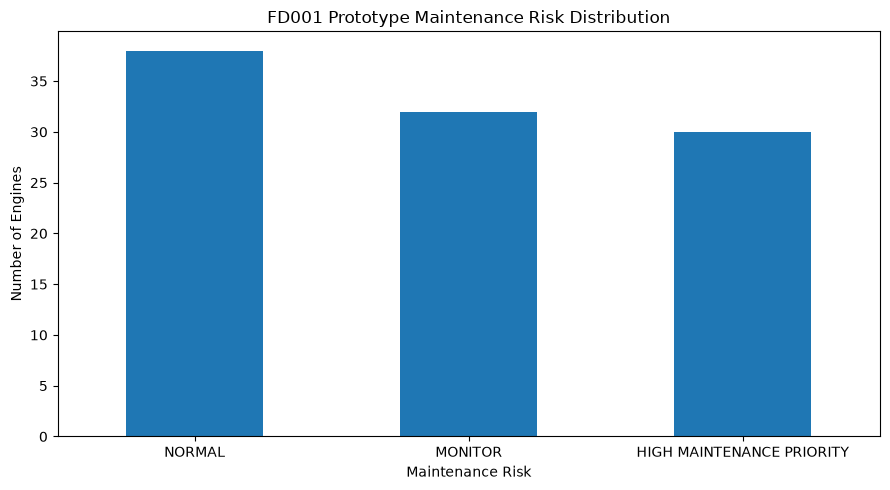

In [11]:
plt.figure(figsize=(9, 5))

risk_counts.plot(kind="bar")

plt.title("FD001 Prototype Maintenance Risk Distribution")
plt.xlabel("Maintenance Risk")
plt.ylabel("Number of Engines")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/FD001_Maintenance_Risk_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Creating the maintainence decision table

In [12]:
maintenance_table = test_predictions[
    [
        "unit",
        "cycle",
        "actual_rul",
        "predicted_rul",
        "absolute_error",
        "maintenance_risk"
    ]
].copy()

maintenance_table = maintenance_table.sort_values(
    "predicted_rul"
)

display(maintenance_table.head(20))

maintenance_table.to_csv(
    "../reports/FD001/maintenance_risk_assessment.csv",
    index=False
)

print(
    "Saved:",
    "../reports/FD001/maintenance_risk_assessment.csv"
)

,unit,cycle,actual_rul,predicted_rul,absolute_error,maintenance_risk
80,81,213,8,5.550903,2.449097,HIGH MAINTENANCE PRIORITY
33,34,203,7,6.060287,0.939713,HIGH MAINTENANCE PRIORITY
34,35,198,11,6.755110,4.244890,HIGH MAINTENANCE PRIORITY
81,82,162,9,7.510115,1.489885,HIGH MAINTENANCE PRIORITY
65,66,147,14,12.003950,1.996050,HIGH MAINTENANCE PRIORITY
75,76,205,10,12.424623,2.424623,HIGH MAINTENANCE PRIORITY
67,68,187,8,13.984462,5.984462,HIGH MAINTENANCE PRIORITY
48,49,303,21,14.773618,6.226382,HIGH MAINTENANCE PRIORITY
55,56,136,15,15.278359,0.278359,HIGH MAINTENANCE PRIORITY
99,100,198,20,15.281925,4.718075,HIGH MAINTENANCE PRIORITY


Saved: ../reports/FD001/maintenance_risk_assessment.csv


## Inspect

In [13]:
high_priority = maintenance_table[
    maintenance_table["maintenance_risk"]
    == "HIGH MAINTENANCE PRIORITY"
]

print(
    "High-priority engines:",
    len(high_priority)
)

display(high_priority)

High-priority engines: 30


,unit,cycle,actual_rul,predicted_rul,absolute_error,maintenance_risk
80,81,213,8,5.550903,2.449097,HIGH MAINTENANCE PRIORITY
33,34,203,7,6.060287,0.939713,HIGH MAINTENANCE PRIORITY
34,35,198,11,6.755110,4.244890,HIGH MAINTENANCE PRIORITY
81,82,162,9,7.510115,1.489885,HIGH MAINTENANCE PRIORITY
65,66,147,14,12.003950,1.996050,HIGH MAINTENANCE PRIORITY
75,76,205,10,12.424623,2.424623,HIGH MAINTENANCE PRIORITY
67,68,187,8,13.984462,5.984462,HIGH MAINTENANCE PRIORITY
48,49,303,21,14.773618,6.226382,HIGH MAINTENANCE PRIORITY
55,56,136,15,15.278359,0.278359,HIGH MAINTENANCE PRIORITY
99,100,198,20,15.281925,4.718075,HIGH MAINTENANCE PRIORITY


In [14]:
print("Lowest predicted RUL:")

display(
    maintenance_table[
        [
            "unit",
            "cycle",
            "predicted_rul",
            "actual_rul",
            "maintenance_risk"
        ]
    ].head(10)
)

Lowest predicted RUL:


,unit,cycle,predicted_rul,actual_rul,maintenance_risk
80,81,213,5.550903,8,HIGH MAINTENANCE PRIORITY
33,34,203,6.060287,7,HIGH MAINTENANCE PRIORITY
34,35,198,6.755110,11,HIGH MAINTENANCE PRIORITY
81,82,162,7.510115,9,HIGH MAINTENANCE PRIORITY
65,66,147,12.003950,14,HIGH MAINTENANCE PRIORITY
75,76,205,12.424623,10,HIGH MAINTENANCE PRIORITY
67,68,187,13.984462,8,HIGH MAINTENANCE PRIORITY
48,49,303,14.773618,21,HIGH MAINTENANCE PRIORITY
55,56,136,15.278359,15,HIGH MAINTENANCE PRIORITY
99,100,198,15.281925,20,HIGH MAINTENANCE PRIORITY


## Creating one example decision

In [15]:
engine_1 = test_predictions[
    test_predictions["unit"] == 1
].iloc[0]

print("AYUSH Maintenance Decision — Engine 1")
print("")
print("Engine:", int(engine_1["unit"]))
print("Current cycle:", int(engine_1["cycle"]))
print("Predicted RUL:", round(engine_1["predicted_rul"], 2))
print("Maintenance risk:", engine_1["maintenance_risk"])

AYUSH Maintenance Decision — Engine 1

Engine: 1
Current cycle: 31
Predicted RUL: 176.19
Maintenance risk: NORMAL


#### Maintenance Decision Support Disclaimer

The maintenance-risk categories used in this prototype are experimental decision rules based on predicted Remaining Useful Life.

They are not real-world defence maintenance standards, safety limits, or operational recommendations.

The thresholds are used only to demonstrate how an RUL prediction could be translated into maintenance-oriented prioritisation.

Real deployment would require equipment-specific failure distributions, engineering analysis, operational constraints, safety requirements, and validation by qualified domain experts.

## Summary

In [16]:
risk_summary = pd.DataFrame({
    "maintenance_risk": risk_counts.index,
    "engine_count": risk_counts.values,
    "percentage": (
        risk_counts.values / len(test_predictions) * 100
    )
})

display(risk_summary)

risk_summary.to_csv(
    "../reports/FD001/maintenance_risk_summary.csv",
    index=False
)

print(
    "Saved:",
    "../reports/FD001/maintenance_risk_summary.csv"
)


,maintenance_risk,engine_count,percentage
0,NORMAL,38,38.0
1,MONITOR,32,32.0
2,HIGH MAINTENANCE PRIORITY,30,30.0


Saved: ../reports/FD001/maintenance_risk_summary.csv
